<a href="https://colab.research.google.com/github/omshahu/ML_Practicals/blob/main/p9_Extra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Omprakash Shahu



In [4]:

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [5]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
path= "/content/drive/MyDrive/ML_Class/WineQT - WineQT.csv"
df=pd.read_csv(path)
df.head(5)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


[2286.0000000000045, 1501.359886091443, 761.3961622476106, 633.4432682350537, 505.9773376469779, 364.2213841246994, 287.7285247528405, 255.17523035093953, 220.57760600687703, 196.71283427684477]


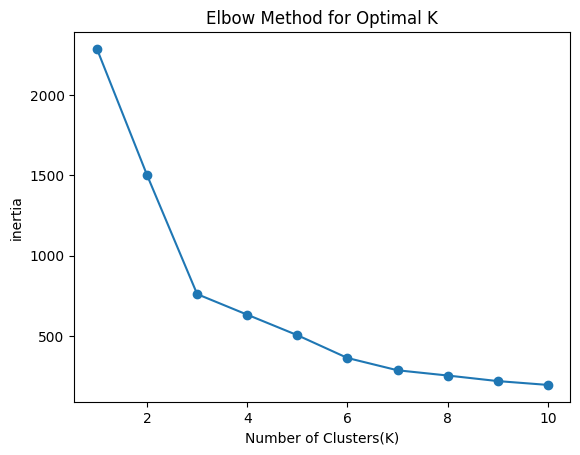

In [7]:
X = df.iloc[:, [3, 4]].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia_values = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

print(inertia_values)

plt.figure()
plt.plot(range(1,11), inertia_values, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters(K)')
plt.ylabel('inertia')
plt.show()

In [8]:
kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset
df['Cluster'] = clusters
(df.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,Cluster
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3,4
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,4


In [9]:
print("Inertia:",kmeans.inertia_)

sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", sil_score)

Inertia: 364.2213841246994
Silhouette Score: 0.3757606462029713


<Axes: xlabel='residual sugar', ylabel='chlorides'>

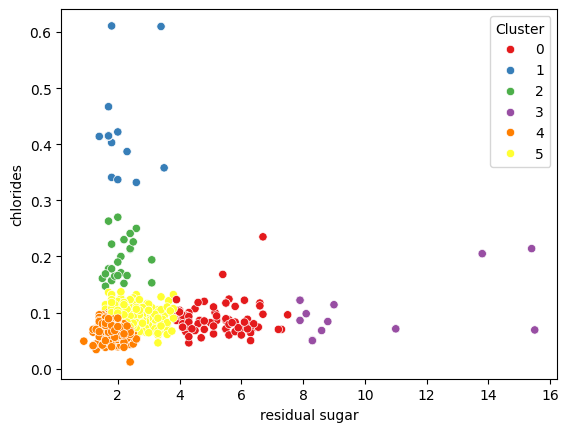

In [10]:

plt.figure()
sns.scatterplot(x='residual sugar',
                y='chlorides' , hue='Cluster',
                data=df, palette='Set1'
)

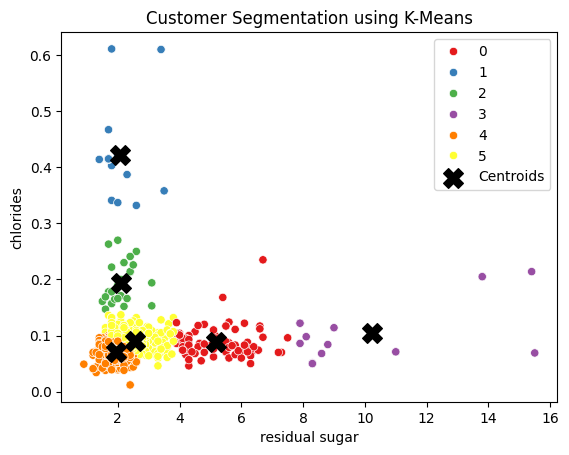

In [11]:
plt.figure()
sns.scatterplot(x='residual sugar',
                y='chlorides' , hue='Cluster',
                data=df, palette='Set1'
)

centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=200, c='black', marker='X',
    label='Centroids'
 )

plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()